In [1]:
!pip install cvxpy --quiet
!conda install -c conda-forge libstdcxx-ng=12.1.0 -y
!pip install cvxopt --quiet


Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done

# All requested packages already installed.



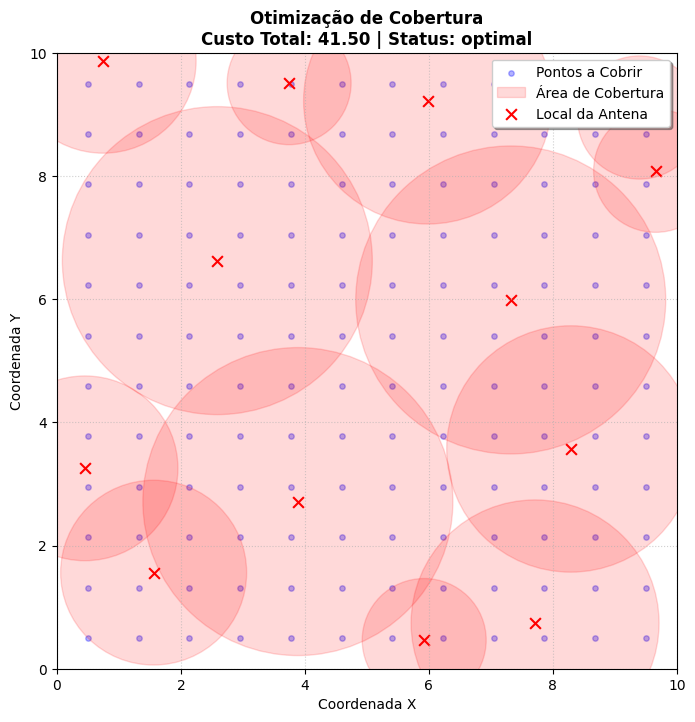

In [10]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configurações ---
L = 10  #lado do quadrado
n_centros = 40  #pontos a serem atendidos        
raio_maximo = 2.5  #cobertura da antena max.   
radii_candidates = [1, 1.5, 2, 2.5,] #raio das antenas 

# Filtragem de raios
radii_candidates = [r for r in radii_candidates if r <= raio_maximo]

np.random.seed(42)
centers = np.random.rand(n_centros, 2) * L
all_centers, all_radii = [], []

for c in centers:
    for r in radii_candidates:
        all_centers.append(c)
        all_radii.append(r)

all_centers = np.array(all_centers)
all_radii = np.array(all_radii)

# --- 2. Grade de Pontos ---
x_grid = np.linspace(0.5, L-0.5, 12)
y_grid = np.linspace(0.5, L-0.5, 12)
X, Y = np.meshgrid(x_grid, y_grid)
points = np.vstack((X.flatten(), Y.flatten())).T

# --- 3. Matriz de Cobertura A ---
A = np.zeros((len(points), len(all_centers)))
for j, p in enumerate(points):
    dist = np.linalg.norm(all_centers - p, axis=1)
    A[j, :] = (dist <= all_radii).astype(int)

# --- 4. Otimização ---
x_var = cp.Variable(len(all_centers), boolean=True)
custo = all_radii**2 
prob = cp.Problem(cp.Minimize(custo @ x_var), [A @ x_var >= 1])
prob.solve(solver=cp.ECOS_BB)

# --- 5. Plotagem com Legenda e Custo ---
if x_var.value is not None:
    selected = np.where(x_var.value > 0.5)[0]
    plt.figure(figsize=(8, 8))
    
    # 1. Plotar pontos da grade (Pontos a Cobrir)
    plt.scatter(points[:, 0], points[:, 1], c='blue', s=15, alpha=0.3, label='Pontos a Cobrir')
    
    # 2. Flags para evitar repetição na legenda
    antena_label_add = False
    cobertura_label_add = False
    
    for i in selected:
        # Área de Cobertura (Círculo)
        lbl_cob = 'Área de Cobertura' if not cobertura_label_add else ""
        circ = plt.Circle(all_centers[i], all_radii[i], color='red', alpha=0.15, label=lbl_cob)
        plt.gca().add_patch(circ)
        cobertura_label_add = True
        
        # Ponto Central da Antena (X)
        lbl_ant = 'Local da Antena' if not antena_label_add else ""
        plt.scatter(all_centers[i, 0], all_centers[i, 1], c='red', marker='x', s=60, label=lbl_ant)
        antena_label_add = True
        
    plt.xlim(0, L)
    plt.ylim(0, L)
    
    # TÍTULO ATUALIZADO COM O CUSTO TOTAL
    # prob.value contém o valor mínimo da função objetivo encontrado pelo solver
    plt.title(f"Otimização de Cobertura\nCusto Total: {prob.value:.2f} | Status: {prob.status}", 
              fontsize=12, fontweight='bold')
    
    plt.xlabel("Coordenada X")
    plt.ylabel("Coordenada Y")
    
    # Exibir legenda organizada
    plt.legend(loc='upper right', scatterpoints=1, frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
else:
    print(f"Status: {prob.status}. Inviável: Tente aumentar n_centros ou os raios.")